In [3]:
from fhfdata import Kantec2509Dataset
import torch
from matplotlib import pyplot as plt
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, random_split

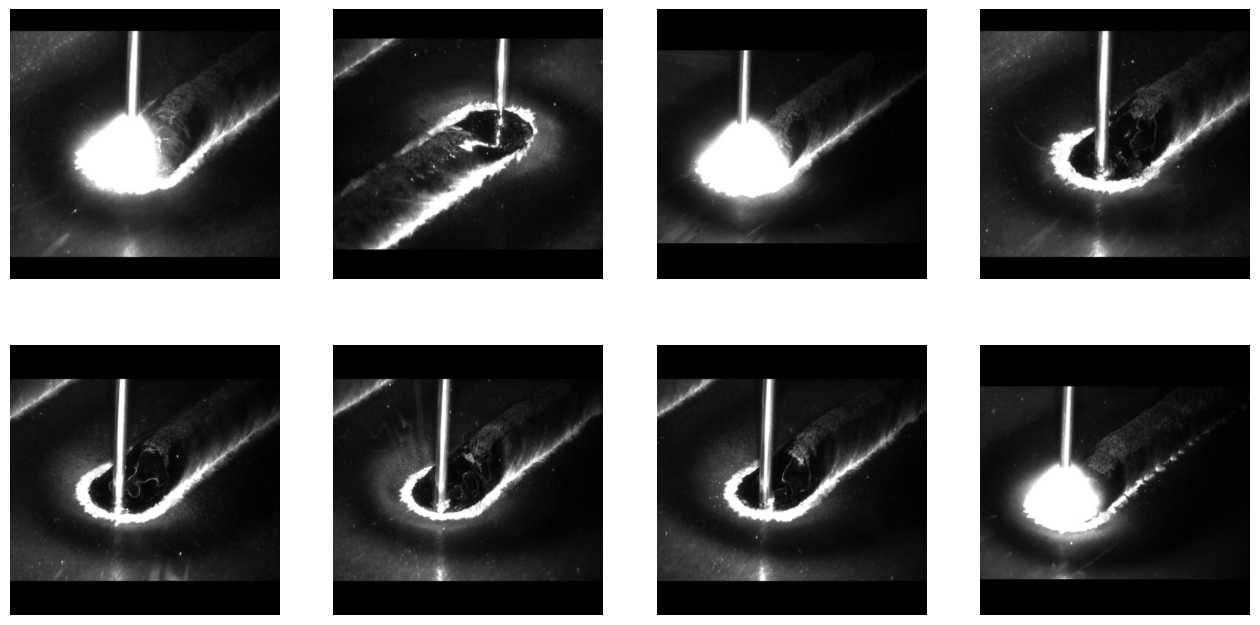

In [4]:
transform = v2.Compose([
    v2.Resize((512, 512)),
    v2.Grayscale(num_output_channels=1),
    # v2.ColorJitter(contrast=(2.0, 2.0)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

dataset = Kantec2509Dataset(transform=transform)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)

batch = next(iter(train_dataloader))
images = batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, img in enumerate(images[:8]):
    img_show = img * 0.5 + 0.5
    axes[i].imshow(img_show.permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")